In [1]:
%config Completer.use_jedi = False

In [2]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorboard as tb 
import pytorch_lightning as pl


from pathlib import Path
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from IPython.core.display import HTML

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

from my_funs import data_processing , get_training , countious_prediction

def path_to_image_html(path):
    return '<img src="'+ path + '" width="1200"  height="500">'

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [3]:
optims = ['SGD' , 'Adadelta' , 'Adam' , 'AdamW', 'Adamax' , 'ASGD' ,'LBFGS','NAdam', 'RAdam' , 'RMSprop' , 'Rprop']
data_path =  'alpha1/02.csv'
result_model_df = pd.DataFrame(columns = ['optim', 'lr' , 'model_ckpt' , 'result_img'])
lr_list = [1e-0 ,1e-1, 1e-2  , 1e-3]
def model_ckpt(idx): 
    return f'optim_test/lightning_logs/version_{idx}/checkpoints/epoch=99-step=2000.ckpt'
IDX = 0

for optim in optims:
    for lr in lr_list:
        result_model_df.loc[IDX , 'optim'] = optim
        result_model_df.loc[IDX , 'lr'] = lr
        result_model_df.loc[IDX , 'model_ckpt'] = model_ckpt(IDX+4)
        result_model_df.loc[IDX , 'result_img'] = None
        IDX += 1

result_model_df

,optim,lr,model_ckpt,result_img
0,SGD,1.0,optim_test/lightning_logs/version_4/checkpoint...,None
1,SGD,0.1,optim_test/lightning_logs/version_5/checkpoint...,None
2,SGD,0.01,optim_test/lightning_logs/version_6/checkpoint...,None
3,SGD,0.001,optim_test/lightning_logs/version_7/checkpoint...,None
4,Adadelta,1.0,optim_test/lightning_logs/version_8/checkpoint...,None
5,Adadelta,0.1,optim_test/lightning_logs/version_9/checkpoint...,None
6,Adadelta,0.01,optim_test/lightning_logs/version_10/checkpoin...,None
7,Adadelta,0.001,optim_test/lightning_logs/version_11/checkpoin...,None
8,Adam,1.0,optim_test/lightning_logs/version_12/checkpoin...,None
9,Adam,0.1,optim_test/lightning_logs/version_13/checkpoin...,None


In [ ]:
epoch = 100
hidden_size = 32
atten_head = 4
batch_size= 32
pl.seed_everything(42)

for idx in result_model_df.index:
    lr = result_model_df['lr'].iloc[idx]
    optim = result_model_df['optim'].iloc[idx]
    print(optim , lr)
    data = data_processing(data_path)
    train_data = data[data['time_idx']  < 8760]
    training = get_training(train_data,24, 24*7)

    dataloader = training.to_dataloader(batch_size)
    validation = TimeSeriesDataSet.from_dataset(training, train_data, predict=True, stop_randomization=True)
    train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size*100, num_workers=0)

    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
    lr_logger = LearningRateMonitor()  
    logger = TensorBoardLogger('optim_test')
    trainer = pl.Trainer(
        max_epochs=epoch,
        gpus=0,
        gradient_clip_val=0.1,
        limit_train_batches=20,  
        callbacks=[lr_logger],
        logger=logger,
    )


    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=lr,
        hidden_size=hidden_size,  # most important hyperparameter apart from learning rate
        # number of attention heads. Set to up to 4 for large datasets
        attention_head_size=atten_head,
        dropout=0.1,  # between 0.1 and 0.3 are good values
        hidden_continuous_size=hidden_size,  # set to <= hidden_size
        output_size=7,  # 7 quantiles by default
        loss=QuantileLoss(),
        # reduce learning rate if no improvement in validation loss after x epochs
        reduce_on_plateau_patience=4,
    )

    tft.hparams['optimizer'] = optim

    trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
    )

    print(trainer.checkpoint_callback.best_model_path)
    result_model_df.loc[idx,'model_ckpt'] = trainer.checkpoint_callback.best_model_path        


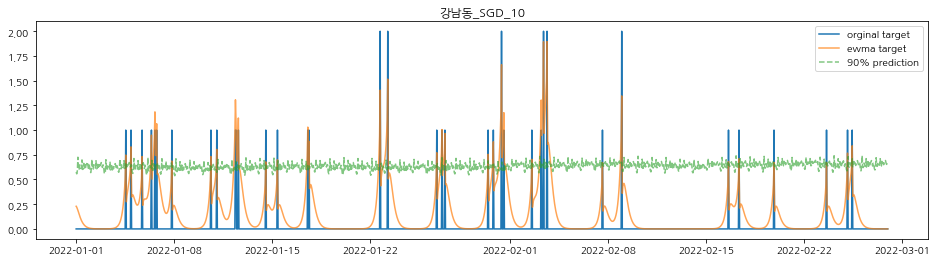

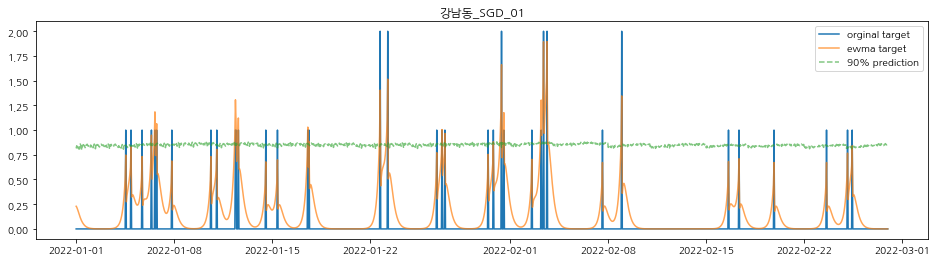

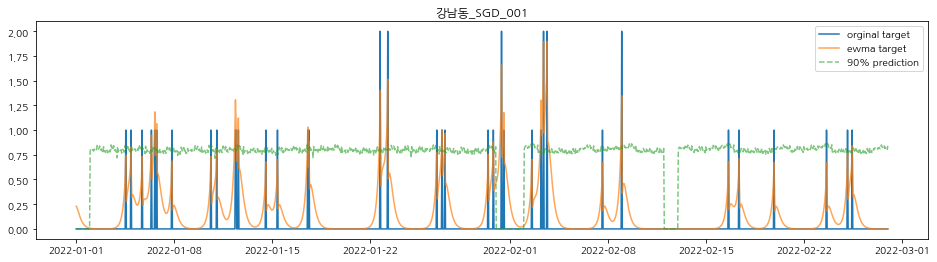

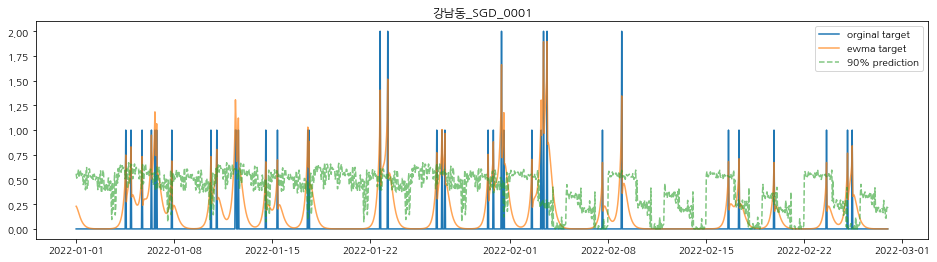

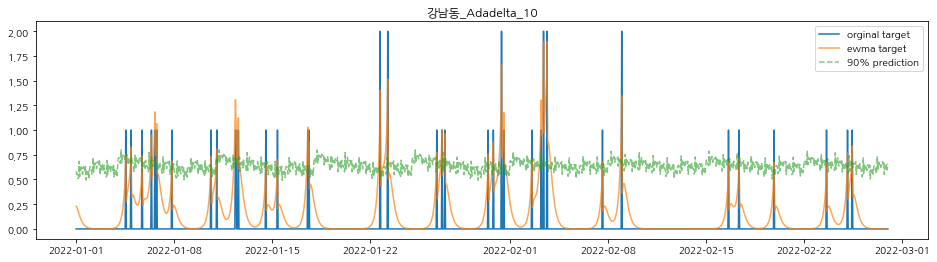

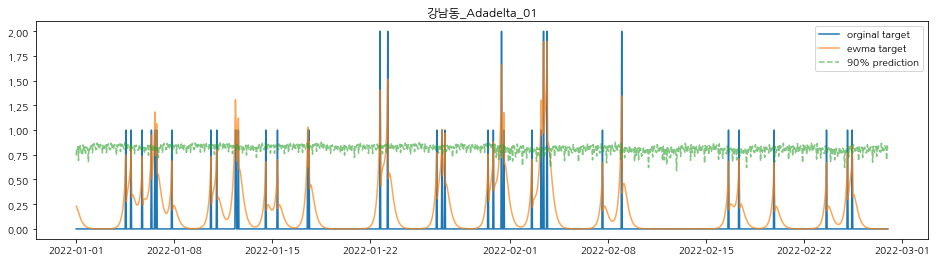

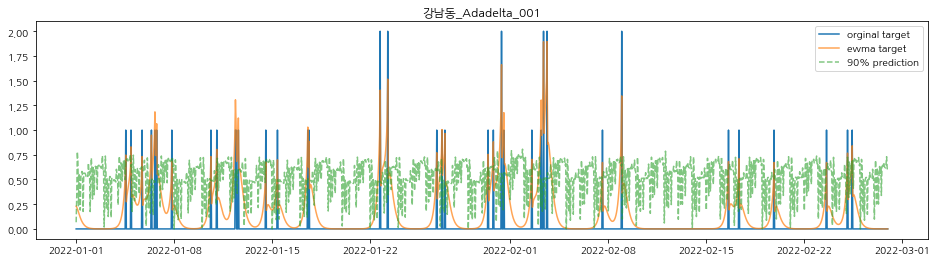

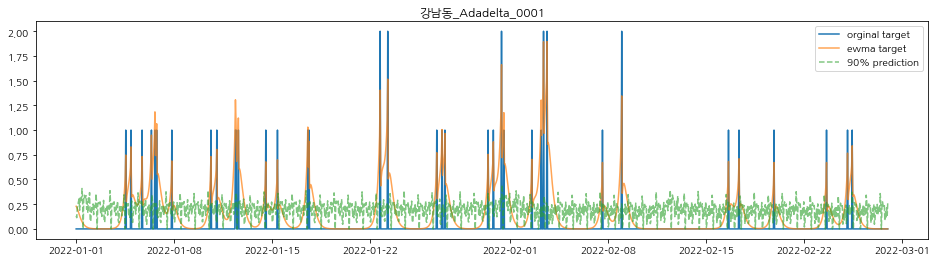

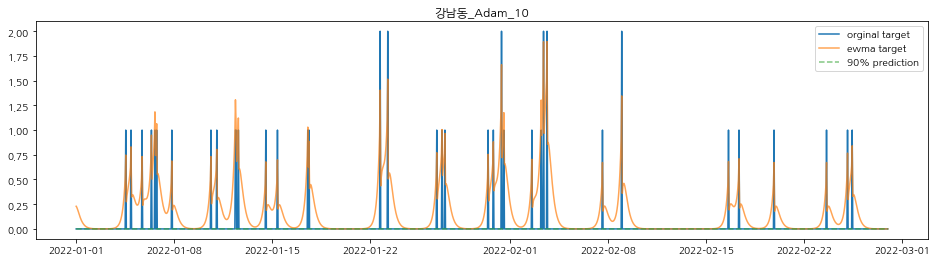

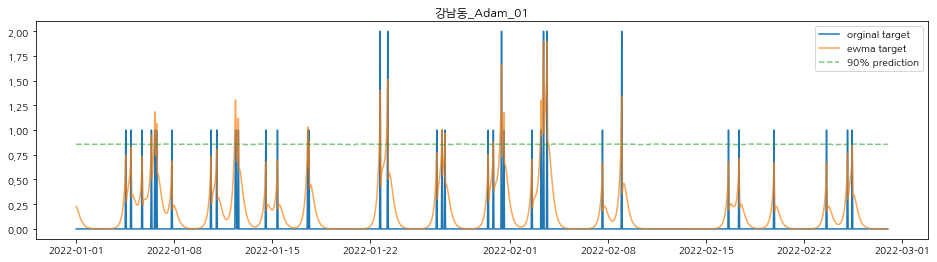

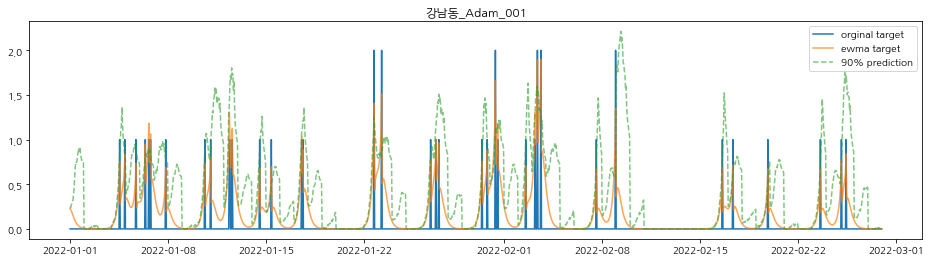

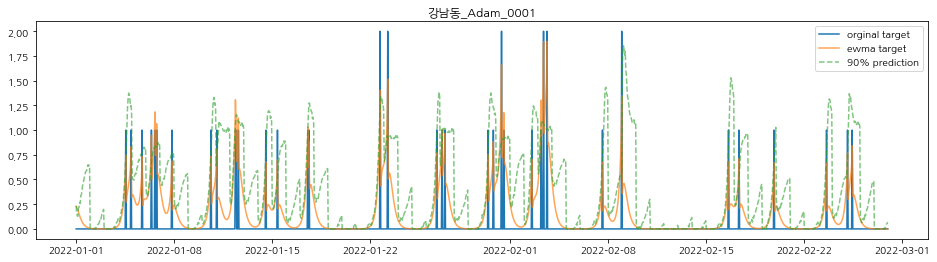

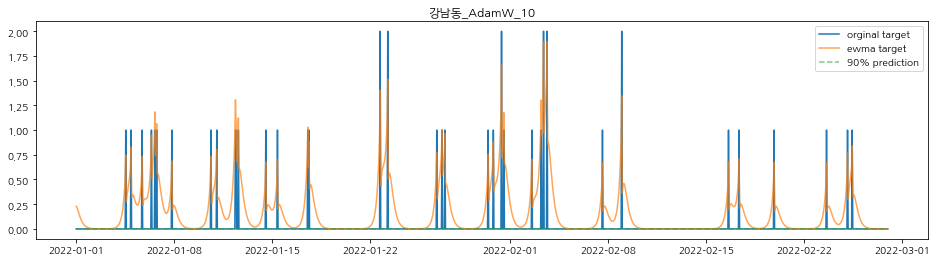

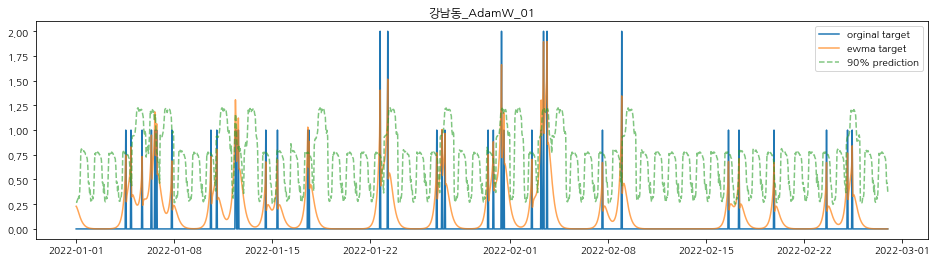

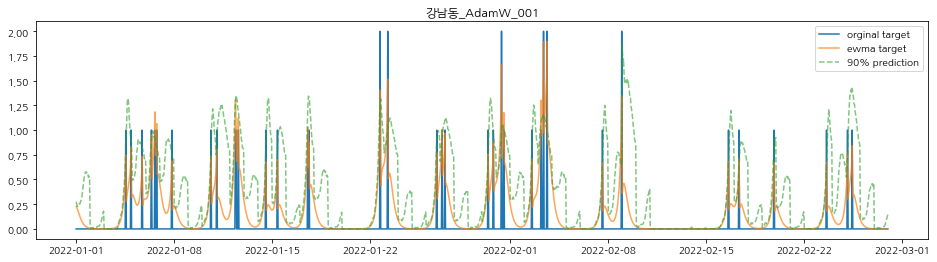

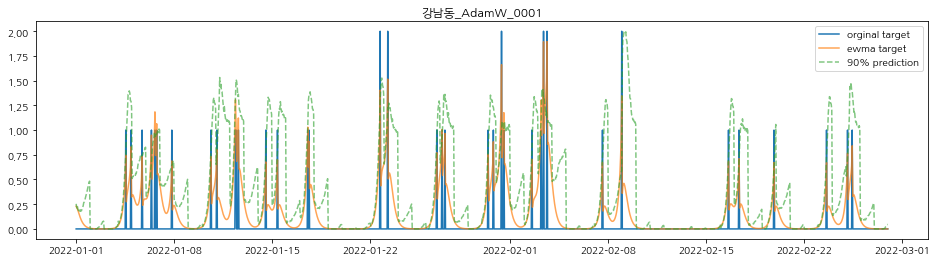

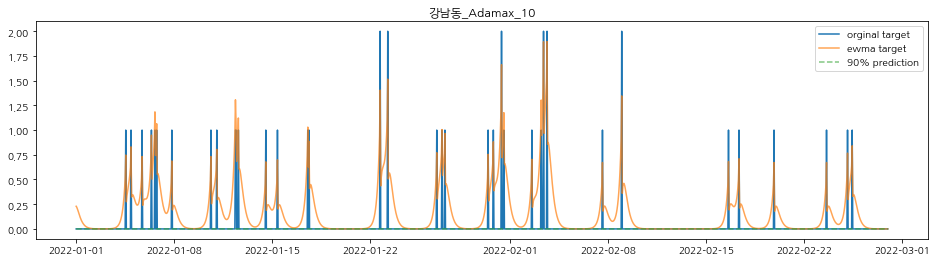

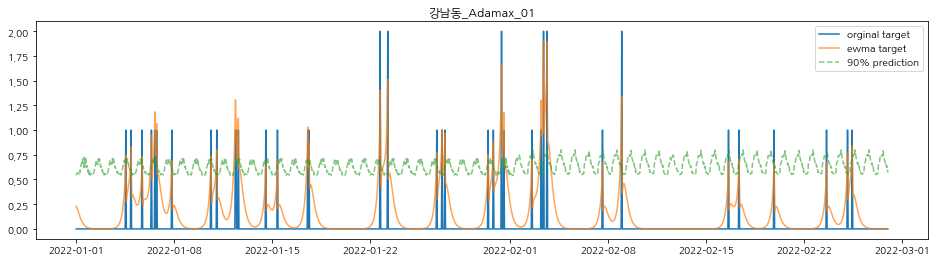

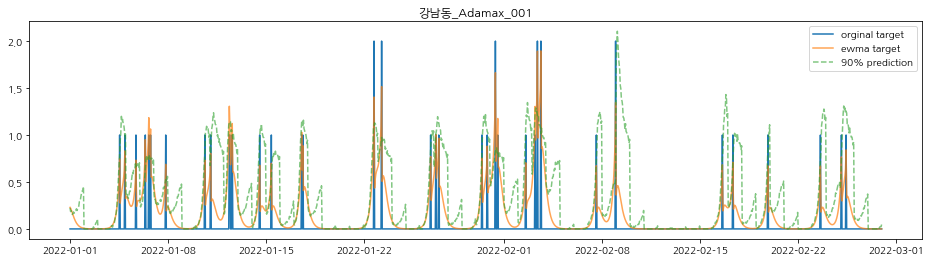

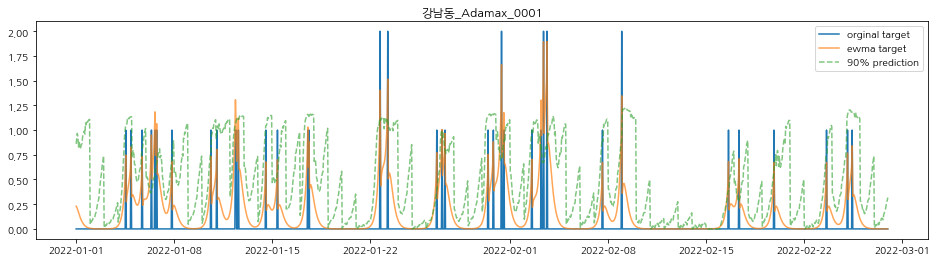

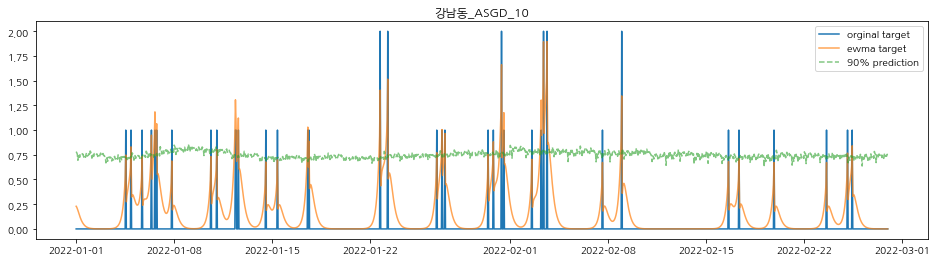

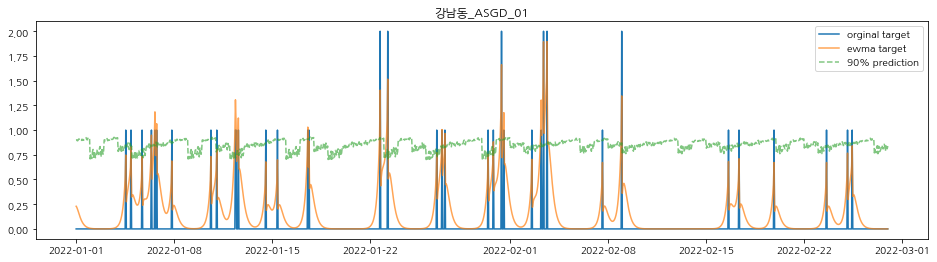

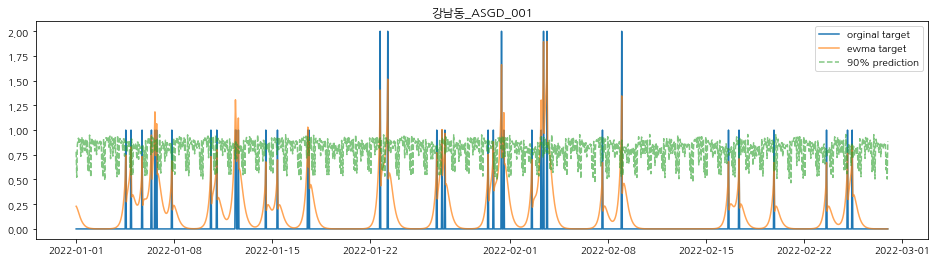

In [4]:
for idx in result_model_df.index[:23]:
    try:
        lr = result_model_df['lr'].loc[idx]
        optim = result_model_df['optim'].loc[idx]
        data = data_processing(data_path)
        model_ckpt = result_model_df['model_ckpt'].loc[idx]
        train_data = data[data['time_idx']  < 8760]
        training = get_training(train_data,24, 24*7)
        tft = TemporalFusionTransformer.load_from_checkpoint(model_ckpt)
        lr = str(lr).replace('.' , '')

        countious_prediction(training, tft, data ,'강남동', f'{optim}_{lr}')
        result_model_df.loc[idx , 'result_img'] = f'강남동_{optim}_{lr}.png'
        #print(idx)
    except:
        pass
    
#cleaned_df= result_model_df.dropna(axis=0)
#with open('2022_11_07_optim_a.html' , 'w') as f:
#    f.write(cleaned_df.to_html(escape=False,formatters=dict(result_img=path_to_image_html)))
#HTML(open('2022_11_07_optim_a.html' , 'r').read())
    

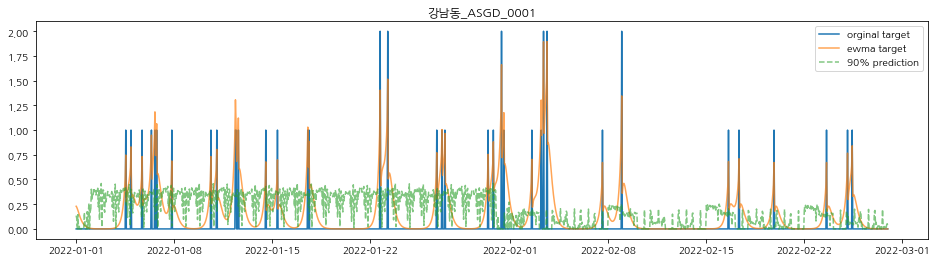

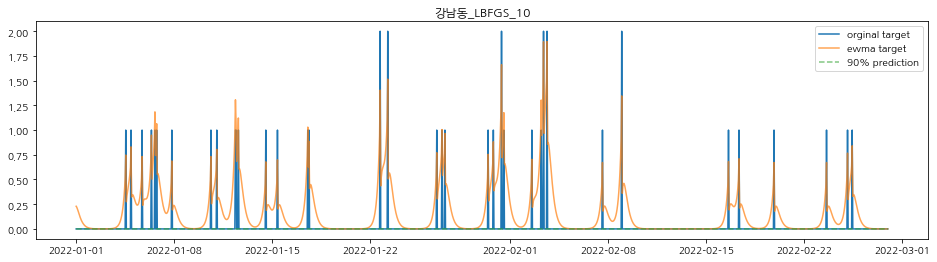

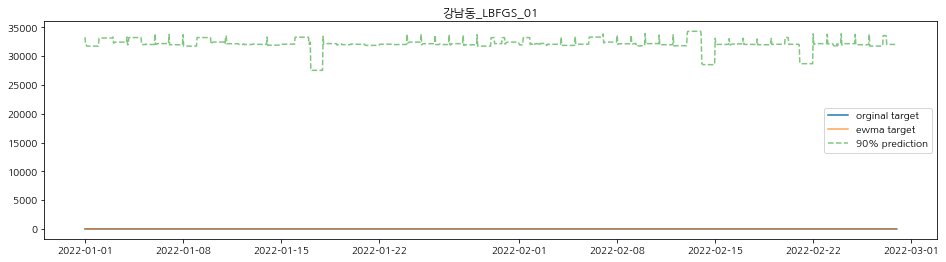

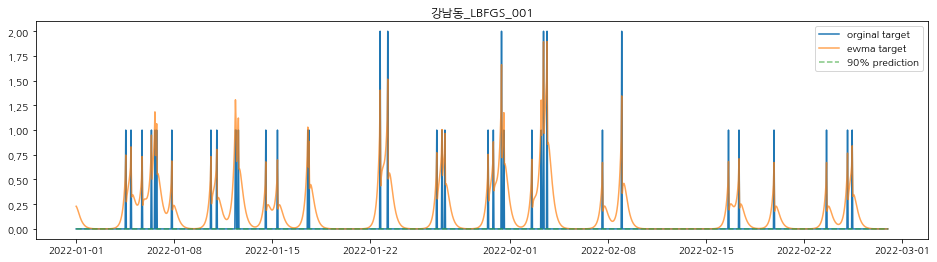

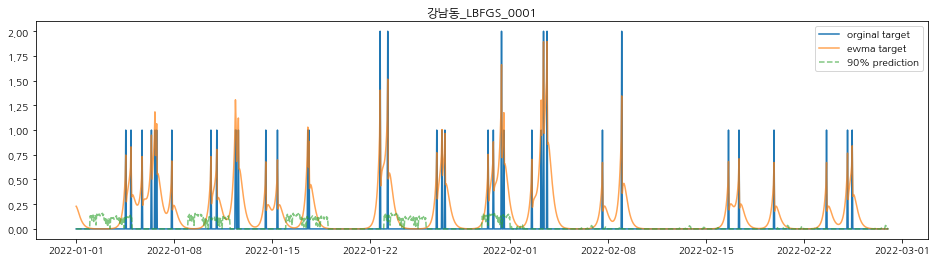

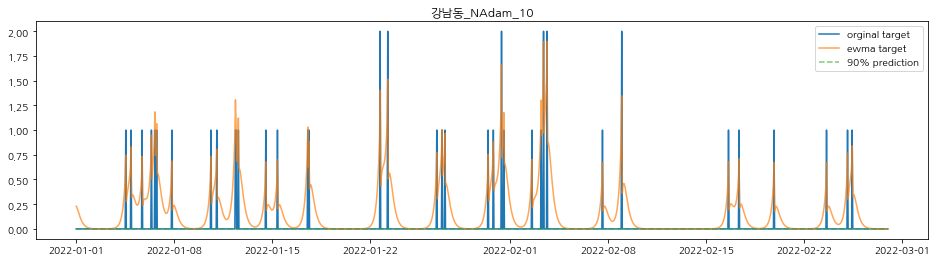

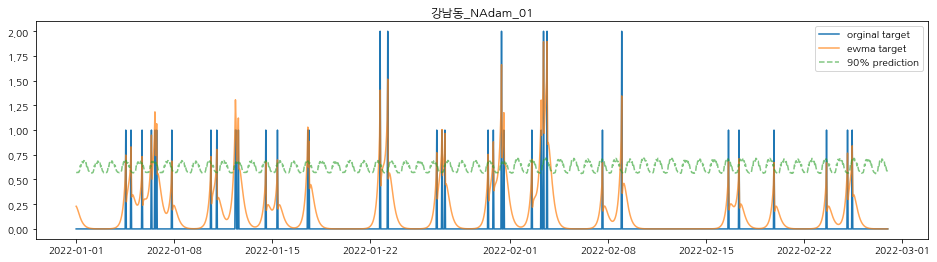

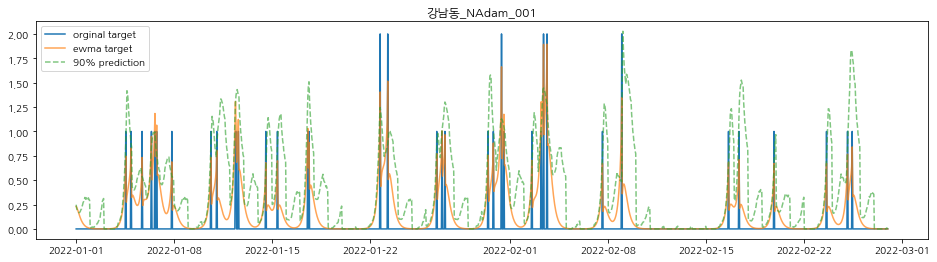

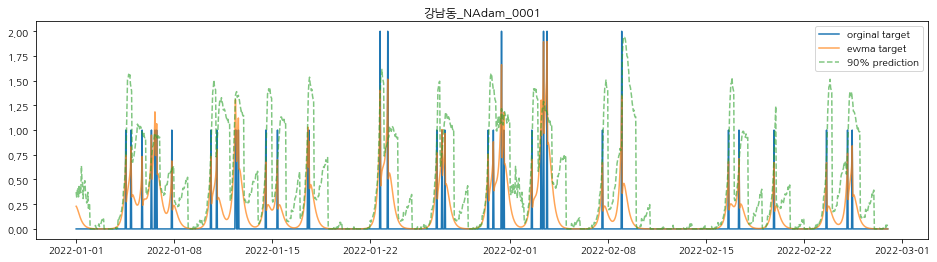

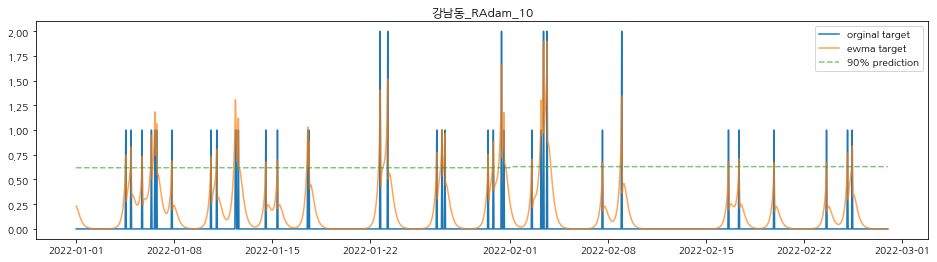

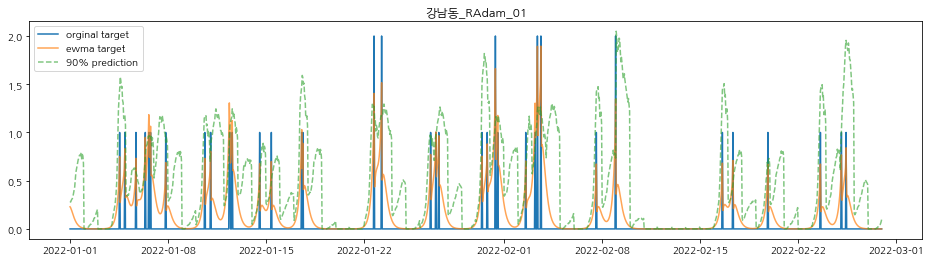

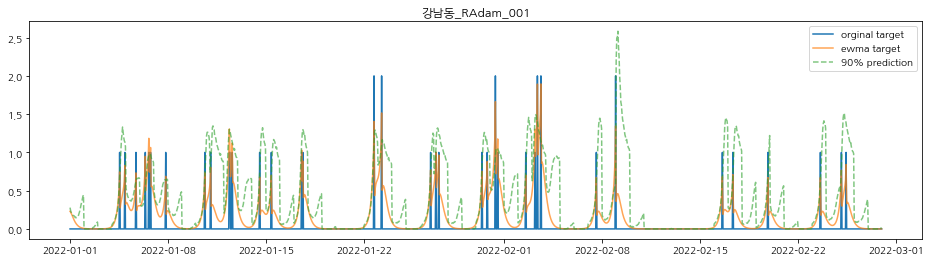

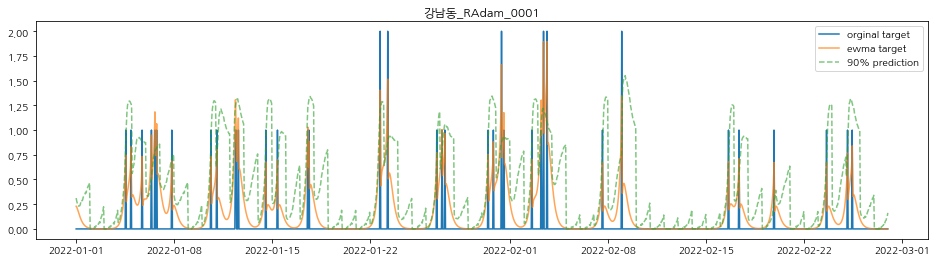

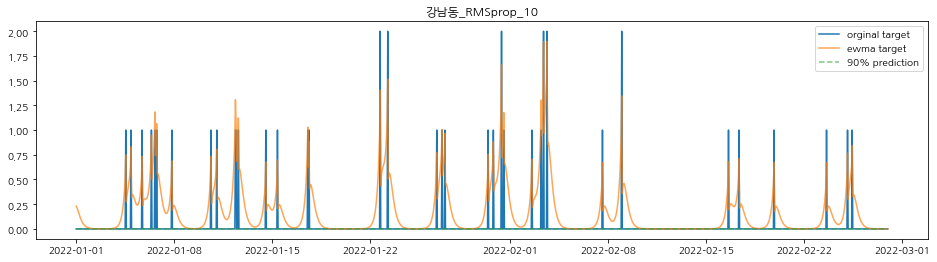

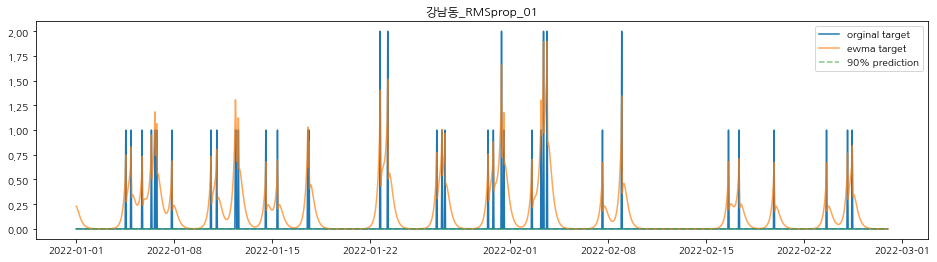

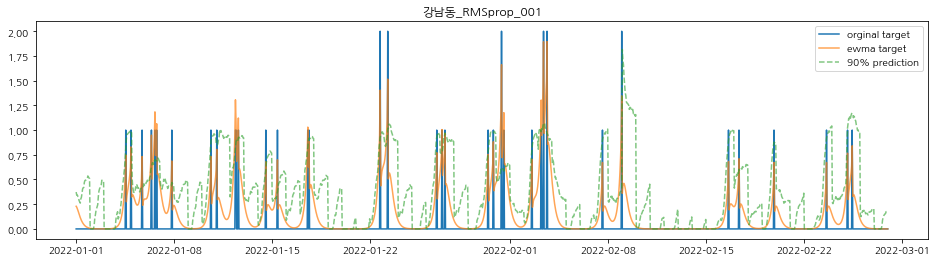

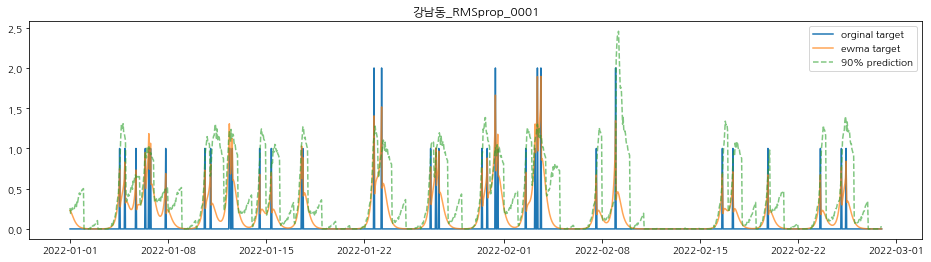

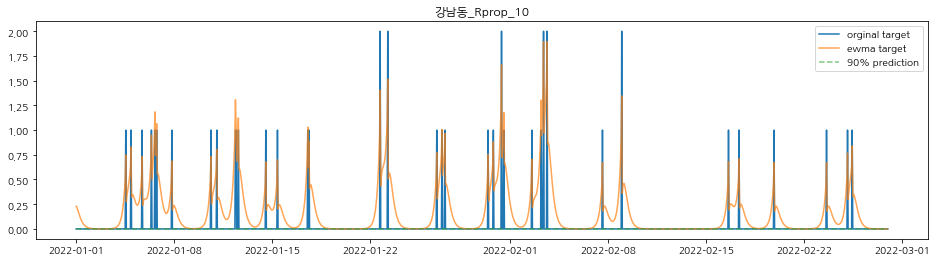

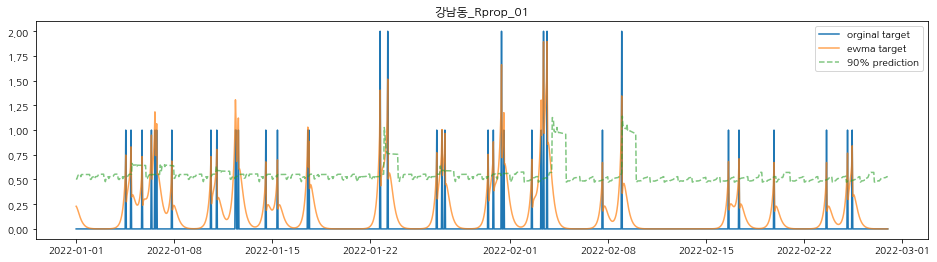

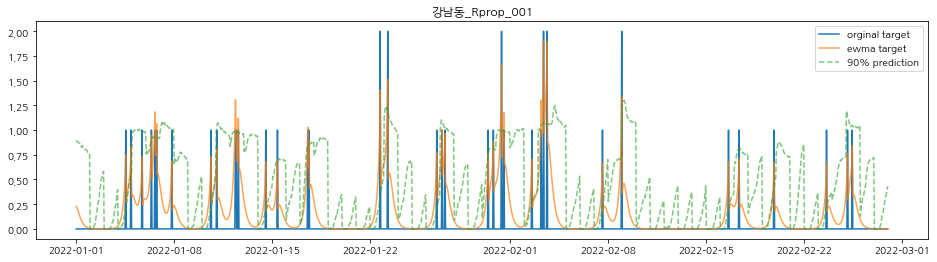

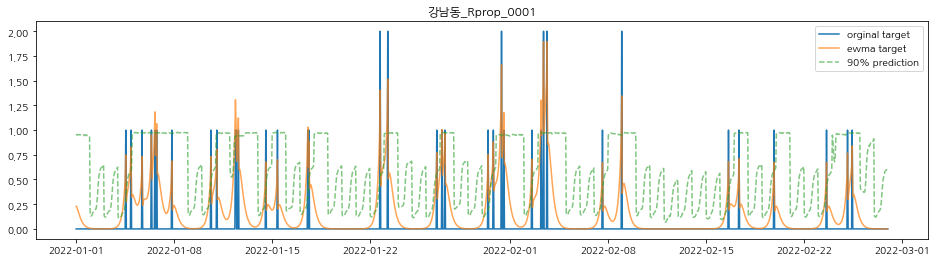

In [4]:
for idx in result_model_df.index[23:]:
    try:
        lr = result_model_df['lr'].loc[idx]
        optim = result_model_df['optim'].loc[idx]
        data = data_processing(data_path)
        model_ckpt = result_model_df['model_ckpt'].loc[idx]
        train_data = data[data['time_idx']  < 8760]
        training = get_training(train_data,24, 24*7)
        tft = TemporalFusionTransformer.load_from_checkpoint(model_ckpt)
        lr = str(lr).replace('.' , '')

        countious_prediction(training, tft, data ,'강남동', f'{optim}_{lr}')
        result_model_df.loc[idx , 'result_img'] = f'강남동_{optim}_{lr}.png'
       # print(idx)
    except:
        pass
    
#cleaned_df= result_model_df.dropna(axis=0)
#with open('2022_11_07_optim_b.html' , 'w') as f:
#    f.write(cleaned_df.to_html(escape=False,formatters=dict(result_img=path_to_image_html)))
#HTML(open('2022_11_07_optim_b.html' , 'r').read())
    